# Training Torchvision Mask R-CNN Model

## Preparations
### Import required libraries

In [1]:
import os
import sys
import numpy as np
import torch
from PIL import Image
import cv2
import random
import pickle
import pycocotools
from pycocotools import mask as coco_mask_util
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from typing import Tuple, Union, List, Dict

We are using Torchvision functions for transforms, training and evaluation in this Notebook. Add them to the path. 
These functions are under `vision/references/detection` folder, where `vision` is the main folder cloned from https://github.com/pytorch/vision. You can simply copy `references/detection` folder and place it under the folder of this Jupyter Notebook. 

Make sure the same installed version is checked out. Also, install pycocotools for evaluation (pip install pycocotools).

In [2]:
# sys.path.append('/home/cellareye/Development/torchvision')
# sys.path.append('/home/cellareye/Development/torchvision/references/detection')
sys.path.append('references/detection')
import references.detection.transforms as T
import references.detection.utils
from references.detection.engine import train_one_epoch, evaluate
sys.path.append('../utils')

## Pre-processing configurations
The following configurations are used for pre-processing the images during the training. 

In [3]:
# percentage of the width/height of each object's bounding box to use for expanding
# the box duing the training
# this is done to ensure the box fully covers the object and prevent cropped masks
PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES = 0.1

# probability of adding random blur and salt-and-pepper or additive gaussian noise to the training images
# see the image Transforms section below
P_NOISE = 0.25

# the lower and upper bounds for random scaling the images (and annotated masks) for training augmentation
MIN_RANDOM_SCALE = 0.8
MAX_RANDOM_SCALE = 1.0

### Transforms

#### Random scaling and cropping
For now random scaling, random cropping and random horizntal flips are considered during the training. We can add random color jitter (if color images), noise addition, hue/saturation modification, random 90 degrees rotation later (these are not implemented in torchvision)

In [4]:
# rescale function
def rescale_sample(image: Image.Image, target: Dict[str, torch.tensor], factor:float) \
-> Tuple[Image.Image, Dict[str, torch.tensor]]:
    
    """
    Rescale the image and the annotated objects in it by a given factor. The
    aspect ratio is kept the same. This function operates on PIL images to ensure
    the resizing of the input images is identical during training and inferencing
    (both should resize PIL images). torchvision.transforms.functional.resize may have a
    slightly different behaviour than PIL.Image.Image.resize and hence is not used 
    to resize the image in torch.tensor type. 

    Args:
        image (input image in PIL.Image.Image format): Input image sample to be scaled. 
        target (dictionary):  The annotations dictionary with a keys and values as 
            defined in torchvision tutorial for Faster and Mask R-CNN (bounding 
            boxes, labels, masks, crowded, area, etc). The target dictionary should 
            have 'boxes', 'area' and optionally 'masks' as keys.  
    returns:
        Resized image in PIL format. 
        target dictionary with resized boxes ('boxes'), masks ('masks') and areas 
        ('area').
    """
    width, height = image.size
    
    target['boxes'] = target['boxes'].mul(factor).round()
    # target['area'] = target['area'].mul(factor ** 2).round()
    target['area'] = (target['boxes'][:, 2] - target['boxes'][:, 0]) * (target['boxes'][:, 3] - target['boxes'][:, 1])
    
    if 'masks' in target:
        # note that mask here is a binary mask and interpolation has to be nearest neighbor to keep 
        # the mask as binary
        target['masks'] = F.resize(img = target['masks'], 
                                   size = [int(height * factor), int(width * factor)], 
                                   interpolation = torchvision.transforms.InterpolationMode.NEAREST)
    
    # keep the ones with postive areas, when shrinking images, it is possible to have 0 as the side of one of the boxes
    valid_ids = target['area'] > 0
    target['boxes'] = target['boxes'][valid_ids]
    target['labels'] = target['labels'][valid_ids]
    target['masks'] = target['masks'][valid_ids]
    target['area'] = target['area'][valid_ids]
    target['iscrowd'] = target['iscrowd'][valid_ids]
    
    # we are resizing the image, which is PIL.Image.Image using cv2 here 
    # (instead of PIL.Image.Image.resize)
    # this is slower and may not be necessary at all, but since cv2.resize() is used
    # during the inference, we try to be consistent here
    
    # use different interpolation schemes depending on factor
    if factor > 1:
        interpolation_scheme = cv2.INTER_CUBIC
    else:
        interpolation_scheme = cv2.INTER_AREA
    
    # convert to numpy, resize and convert back to PIL
    image = cv2.resize(np.array(image), (int(width * factor), int(height * factor)), interpolation_scheme)
    image = Image.fromarray(image)
    
    return image, target

# random crop function
def random_crop_sample(image: Image.Image, target: Dict[str, torch.tensor], width: int, height: int) \
-> Tuple[Image.Image, Dict[str, torch.tensor]]:
    """
    Randomly crop or expand the image and update the annotated objects passed 
    in target dictionary by a given set of sizes (width and height). The input
    image will be cropped (made smaller) if at least one of the input sizes 
    (width and height) is less than the image dimensions. When cropping, the 
    bounding boxes that lies outside the newly cropped image by more than 20%
    (i.e., 20% or more of the object's area lies outside the cropped image) will
    be removed and the part of the object left inside the cropped image will be 
    blacked out (to be ignored during training). 
    If both input sizes are larger than the image sizes, the image will be 
    randomly expanded on 4 sides by zero padding to return an image with the
    specified dimensions. 
    If only one of the input sizes is less than the image sizes, the image will
    be cropped. In this case, the image will not be expanded beyond it size. 

    Args:
        image (input image in PIL.Image.Image format): Input image sample to be scaled. 
        target (dictionary):  The annotations dictionary with a keys and values as 
            defined in torchvision tutorial for Faster and Mask R-CNN (bounding 
            boxes, labels, masks, crowded, area, etc). The target dictionary should 
            have 'boxes', 'area' and optionally 'masks' as keys.  
        width (integer): Width of the cropped image in pixels. 
        height (integer): Height of the cropped image in pixels. 
    returns:
        Resized image in PIL format. 
        target dictionary with resized boxes ('boxes') and areas ('area').
    """
        
    w, h = image.size
    
    image_array = np.array(image)
    rgb_image = len(image_array.shape) > 2
    
    
    if h < height and w < width:
        # randomly enlarge the image by zero padding
        x1 = np.random.randint(0, width - w)
        y1 = np.random.randint(0, height - h)
        
        if rgb_image:
            # sizes of the expanded image
            expanded_image = np.zeros((height, width, 3), dtype = 'uint8')
        else:
            expanded_image = np.zeros((height, width), dtype = 'uint8')
            
        expanded_image[y1:y1+h, x1:x1+w] = image_array    
        image = Image.fromarray(expanded_image)
        
        # this should never happen
        if len(target["labels"]) == 0:
            # no annotated object in this image, return the cropped image
            return image, target
    
        target["boxes"][:, 0] += x1
        target["boxes"][:, 1] += y1
        target["boxes"][:, 2] += x1
        target["boxes"][:, 3] += y1
        
        if 'masks' in target:
            out_masks = []
        
            for idx in range(target['masks'].shape[0]):
                expanded_mask = torch.zeros((height, width), dtype=torch.uint8)
                expanded_mask[y1:y1+h, x1:x1+w] = target['masks'][idx]
                out_masks.append(expanded_mask)
        
            target["masks"] = torch.as_tensor(torch.stack(out_masks, dim=0), dtype = torch.uint8)
        
        
        return image, target
    
    
    # crop the image, note that in the following, we will not zero pad
    # the image if one of the input crop sizes is larger than the image size
    if h > height:
        yc1 = np.random.randint(0, h - height)
        yc2 = yc1 + height
    else:
        yc1 = 0
        yc2 = h
    if w > width:
        xc1 = np.random.randint(0, w - width)
        xc2 = xc1 + width
    else:
        xc1 = 0
        xc2 = w

    image = image.crop((xc1, yc1, xc2, yc2))
    
    if len(target["labels"]) == 0:
        # no annotated object in this image, return the cropped image
        return image, target
    
    image_array = np.array(image)
    
    bbox = target["boxes"].detach().numpy()
    areas = target["area"].detach().numpy()
    labels = target["labels"].detach().numpy()
    
    
    bbox[:, 0] -= xc1
    bbox[:, 1] -= yc1
    bbox[:, 2] -= xc1
    bbox[:, 3] -= yc1
        
    # sizes of cropped image
    crop_width = xc2 - xc1
    crop_height = yc2 - yc1
    
    out_boxes = []
    out_areas = []
    out_labels = []
    
    if 'masks' in target:
        out_masks = []
        masks = target["masks"].detach().numpy()
    
    num_objects = 0
    for i, box in enumerate(bbox):
        # remove bounding boxes that would lie outside the newly cropped
        # image by more than 20%
        
        box[0] = max(box[0], 0)
        box[1] = max(box[1], 0)
        box[2] = min(box[2], crop_width)
        box[3] = min(box[3], crop_height)
        
        area = max(0, box[2] - box[0]) * max(0, box[3] - box[1])
        
        # skip the box if it lies totally outside the cropped image
        if area == 0:
            continue
        
        if area >= 0.33 * areas[i] > 0 and int(box[0]) < int(box[2]) and int(box[1]) < int(box[3]):
            out_boxes.append(box)
            out_areas.append(area)
            out_labels.append(labels[i])
            
            if 'masks' in target:
                out_masks.append(masks[i, yc1: yc2, xc1: xc2])
            
            num_objects += 1
        else:
            # blackout the image
            if rgb_image:
                image_array[int(box[1]):int(box[3]), int(box[0]):int(box[2]), :] = (0, 0, 0)
            else:
                image_array[int(box[1]):int(box[3]), int(box[0]):int(box[2])] = 0
    
    image = Image.fromarray(image_array)
    

    if num_objects > 0:
        target["boxes"] = torch.as_tensor(np.array(out_boxes), dtype = torch.float32)
        target["area"] = torch.as_tensor(np.array(out_areas), dtype = torch.float32)
        target["labels"] = torch.as_tensor(np.array(out_labels), dtype = torch.int64)
        if 'masks' in target:
            target["masks"] = torch.as_tensor(np.array(out_masks), dtype = torch.uint8)
        target["iscrowd"] = torch.zeros((num_objects,), dtype=torch.int64)
    
    else:
        target["boxes"] = torch.empty((0, 4), dtype = torch.float32)
        target["area"] = torch.empty((0,), dtype = torch.float32)
        target["labels"] = torch.empty((0,), dtype = torch.int64)
        if 'masks' in target:
            target["masks"] = torch.empty((0, crop_height, crop_width), dtype = torch.uint8)
        target["iscrowd"] = torch.empty((0,), dtype = torch.int64)
        
    return image, target

In [5]:
# random scale transform class
class RandomScale(object):
    """
    Class for random scaling the image while keeping the aspect ratio the same. 
    Scale factor is chosen randomly from a given range of scales.
    """
    def __init__(self, min_range, max_range):
        """
        Args: 
            min_range (float): The lower bound on the scale factor.
            max_range (float): The upper bound on the scale factor. 
        """
        if min_range >= max_range:
            print('[ERROR]: min range for scaling should be less than or equal to the max range.')
            print('The class was not instantiated.')
            return
        self.min_range = min_range
        self.max_range = max_range

    def __call__(self, image, target):
        """
        Scale the image and the annotations by a factor randomly (uniformly) chosen 
        from [self.min_range, self.max_range]. Note that the input image should be in 
        PIL format unlike the transforms class under torchvision.references.detection.tranforms.py 
        that takes tensors. So when combined with other transforms, this should be called first on 
        the PIL image before the image is converted to Tensor. 
        
        Args:
            image (input image in PIL.Image.Image format): Input image sample to be scaled. 
            target (dictionary):  The annotations dictionary with a keys and values as 
                defined in torchvision tutorial for Faster and Mask R-CNN (bounding 
                boxes, labels, masks, crowded, area, etc). The target dictionary should 
                have 'boxes', 'area' and optionally 'masks' as keys.  
        Returns: 
            Scaled image and annotations by a randomly chosen factor in 
                [self.min_range, self.max_range]. The return image is the same size as the input
                image and the aspect ratio is kept the same during scaling. If the 
                scale factor is less than 1, the returned image is zero padded to the
                same size as the input image. 
        """
        # keep a copy of the image and target dictionary
        # if no object remains in the target dictionary after rescaling and cropping
        # we return the original input unmodified
        
        boxes = target['boxes'].detach().clone()
        area = target['area'].detach().clone()
        labels = target['labels'].detach().clone()
        
        if 'masks' in target:
            masks = target['masks'].detach().clone()
        
        img = image.copy()
        
        w, h = image.size
        factor = random.random() * (self.max_range - self.min_range) + self.min_range
        image, target = rescale_sample(image, target, factor)
        image, target = random_crop_sample(image, target, w, h)
        # check if target include any non-background class
        if (target['labels'] > 0).any():
            return image, target
        
         # return the original image and target dictionary 
        target['boxes'] = boxes
        target['labels'] = labels
        target['area'] = area
        if 'masks' in target:
            target['masks'] = masks
        target['iscrowd'] = torch.zeros((len(labels),), dtype=torch.int64)
        
        return img, target

#### Other Augmentations
In the following, we define classes for the following additional augmentation of the training images. None of the transforms below change the bounding boxes. They only change the image 'quality':
- Gaussian Blur with sigma randomly selected between 0, 2.0
- Drop-out (salt and pepper noise) with p randomly selected between 0, 0.02, where p is the percentage of dropped out pixels
- Additive Gaussian Noise with sigma randomly selected between 0, 10 out of 255

In [6]:
from imgaug import augmenters

# in the following classes, we use imgaug package to modify images
class ImgAugTransform(object):
    """
    Class to randomly modify the image by adding Gaussian blur (with sigma randomly
    selected between 0, 2.0), Dropout (with p randomly selected between 0, 0.02, where
    p is the percentage of dropped out pixels) and additive Guassian noise (with sigma
    randomly selected between 0, 10 out of 255 for all channel); 
    each modification is applied indepedently with probability 0.25 
    (Note: Either of drop out or additive Gaussian is applied at any time a modification 
    is made)
    No change is made to the annotations. 
    """
    
    def __init__(self, p=0):
        self.aug = augmenters.Sequential([
            # Gaussian blur with p probability
            augmenters.Sometimes(p, augmenters.GaussianBlur(sigma=(0, 2.0))),
            # either of Droput or AdditiveGaussianNoise with probability p
            augmenters.Sometimes(p,
                                 augmenters.OneOf(
                                      [augmenters.Dropout(p=(0, 0.02)), 
                                       augmenters.AdditiveGaussianNoise(scale=(0, 10.0))]
                                ))
            ])

    def __call__(self, image, target):
        """ 
        Args:
            image (input image in PIL.Image format): Input image sample to be modified. 
            target (dictionary):  The annotations dictionary with a keys and values as 
                defined in torchvision tutorial for Faster and Mask R-CNN (bounding 
                boxes, labels, masks, crowded, area, etc).
        Returns: 
            modified image and annotations (no change to annotations). 
        """
        # imgaug accept images in numpy H x W x 3 RGB format, 
        # convert the PIL image to a numpy array before applying the
        # transforms
        outImg = self.aug.augment_image(np.array(image))
        # convert back to PIL image before returning
        return Image.fromarray(outImg), target

/home/cellareye/python-envs/PyTorch/lib/python3.8/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/cellareye/python-envs/PyTorch/lib/python3.8/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/cellareye/python-envs/PyTorch/lib/python3.8/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/cellareye/python-envs/PyTorch/lib/python3.8/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [7]:
def get_transform(train: bool = True) -> references.detection.transforms.Compose:
    trsfms = []
    if train:
        # random noise addition and random scale as defined above, 
        # we call these before PILToTensor as these classes 
        # operates on PIL images
        trsfms.append(ImgAugTransform(p=P_NOISE))
        trsfms.append(RandomScale(MIN_RANDOM_SCALE, MAX_RANDOM_SCALE))
        trsfms.append(T.PILToTensor())
        # ToTensor() has been removed from references.detection.transforms 
        # in newer torchvision versions and has been replaced by ToPILTensor
        # for earlier torchvision, use trsfms.append(T.ToTensor())
        trsfms.append(T.RandomHorizontalFlip(0.5))
    else:
        # test set (only convert to Tensor)
        trsfms.append(T.PILToTensor())
        # for earlier torchvision versions, use
        # trsfms.append(T.ToTensor())
    return T.Compose(trsfms)

## Data Model
The dataset classes as well as the training scripts are taken from the PyTorch official tuturial (https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html). This Notebook provides 3 dataset classes for the following data types:

1. Cell mask annotations generated by running CellPose (one class only). Used initially when no annotated data was available and is no longer relevant. 

2. JSON annotations from the annotators and without any pre-precessing (mainly resizing and cropping to smaller sub-images).

3. Pre-processed annotated data (resized and cropped)

Only use one of the options below for training. 

### 1. One-class dataset for CellPose generated data


The dataset is built by passing the location of the images folder and the masks folder. The code below assumes the images and the corresponding masks use the same name. For each image with name `sample_name` (saved as .jpg or .png) under the images folder, there should be a mask with the same name and .png extension (`sample_name.png`) under the masks folder.  

The masks produced by CellPose are numpy arrays of the same size as the input images with unsigned 16-bit elements (dtype=np.uint16). These arrays can be saved as .png imaegs by using `PIL.Image.save()`. 


<code>
img_out = Image.fromarray(mask_numpy_array_from_cellpose)
img_out.save('mask.png')
</code>

In [ ]:
class CellMaskDataset(torch.utils.data.Dataset):
    def __init__(self, images_path: str, masks_path: str, 
                 transforms: references.detection.transforms.Compose,
                 color_depth: int = 13, 
                 normalize:bool = False) -> None:
        self.images_path = images_path
        self.masks_path = masks_path
        self.transforms = transforms
        # load all images and masks
        # the assumption is the image and its mask annotation use the same name
        self.imgs = list(sorted(os.listdir(images_path)))
        self.masks = list(sorted(os.listdir(masks_path)))
        # the scaling factor for normalizing the channels after Tensor
        # conversion to get values in [0, 1]
        # this is 2 ^ color_depth - 1, where color_depth is the number of bits
        # use to represent the intensities for each channel
        self.channel_scale = 2 ** color_depth - 1
        self.normalize = normalize
        
        if len(self.imgs) != len(self.masks):
            print("[ERROR]: The list of images and masks are not consistent")
            return
        
        for i, img_filename in enumerate(self.imgs):
            # drop the image/mask filename extension 
            # (anything after the last '.' in the filename is considered as extension)
            img_name = ".".join(img_filename.strip().split('.')[:-1])
            mask_name = ".".join(self.masks[i].strip().split('.')[:-1])
            if img_name != mask_name:
                print("[ERROR]: Inconsistent mask file :{} found for image file: {}".format(mask_name, img_name))
     

    def __getitem__(self, idx: int):
        # load images and masks
        img_path = os.path.join(self.images_path, self.imgs[idx])
        mask_path = os.path.join(self.masks_path, self.masks[idx])
        # read the image, do not change the format
        # depending on the set color_depth, the values will be in [0, 2^color_depth - 1]
        img = Image.open(img_path)
        
        # the assumption here is instances are encoded as different levels
        # with 0 being the background
        # each element in mask is an np.uint16 (unsigned 16 bits)
        # we can read such images using PIL.Image
        # convert to a numpy array
        mask = np.array(Image.open(mask_path))
        # instances are encoded as different gray levels
        # the results are sorted
        obj_ids = np.unique(mask)
        # first id [0] is the background, so remove it
        obj_ids = obj_ids[1:]
        
        # get bounding box coordinates for each mask
        num_objs = len(obj_ids)
        
       
        # split the color-encoded mask into a set
        # of binary masks
        masks = mask == obj_ids[:, None, None]

        boxes = []
        valid_ids = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            if xmin < xmax and ymin < ymax:
                valid_ids.append(i)
                boxes.append([xmin, ymin, xmax, ymax])
        
        num_objs = len(valid_ids)
        # there is only one class (cell)
        labels = torch.ones((num_objs,), dtype=torch.int64)    
            
        # convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        
        # masks, at this point the masks are binary (0, 1) so uint8 is fine
        masks = torch.as_tensor(masks[valid_ids], dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)
            # convert the returned np.unit32 image to float with values between 0, 1
            # Note: in the newer torchvision versions where ToTensor() class
            # has been removed from references.detection.transforms and replaced by ToPILTensor
            # the scaling should be done after the conversion 
            # for earlier torchvision, convert the Image to a numpy array, scale it properly 
            # 0, 255 with dtype = np.uint8 and then convert to a tensor
            if self.normalize:
                # if this flag is set, normalize the image such the the minimum intensity 
                # is mapped to zero, and the maximum is mapped to one
                min_value = img.min()
                max_value = img.max()
                img = (img - min_value).div(max_value - min_value + 1e-30).to(torch.float32)
            else:    
                # the intensity of the images is color_deptj bits, so we need to divide by 2^color_depth - 1
                img = img.div(self.channel_scale).to(torch.float32)

        return img, target

    def __len__(self):
        return len(self.imgs)

#### Dataset prepration for option 1
----------------

Set the `color_depth` and the `normalize` flag properly!

In [ ]:
# For one class CellPose generated data
TRAIN_IMAGES_PATH = '/home/cellareye/Cellanome/Images/img/images'
TRAIN_MASKS_PATH = '/home/cellareye/Cellanome/Images/img/masks'

TEST_IMAGES_PATH = '/home/cellareye/Cellanome/Images/img/test/images'
TEST_MASKS_PATH = '/home/cellareye/Cellanome/Images/img/test/masks'

# use our dataset and defined transformations
train_dataset = CellMaskDataset(images_path=TRAIN_IMAGES_PATH, masks_path=TRAIN_MASKS_PATH, 
                                transforms=get_transform(train=True), color_depth = 14, normalize=False)

test_dataset = CellMaskDataset(images_path=TEST_IMAGES_PATH, masks_path=TEST_MASKS_PATH, 
                                transforms=get_transform(train=False), color_depth = 14, normalize=False)

### 2. Multi-class dataset for JSON annotations (from the annotators)
To parse the annotation JSON files by the annotators and used them for training, use the class below. This class supports multiple object classes. Resizing of all images is supported by passing maximum limits on the smaller and the larger sides of the images. 

In [ ]:
from json_parser import parse_json_annotations

class CellMaskDataset(torch.utils.data.Dataset):
    def __init__(self, images_path: str, annotations_path: str, 
                 transforms: references.detection.transforms.Compose,
                 class_names_to_ids_map: dict, 
                 labels_of_interest: Union[List[str], None] = None, 
                 color_depth: int = 14, min_diameter_for_annotated_objects: int = 0.0,
                 max_larger_side: int = 2000, max_smaller_side: int = 1600, 
                 normalize:bool = False) -> None:
        self.images_path = images_path
        self.annotations_path = annotations_path
        self.transforms = transforms
        # load all images and mask annotations
        # the assumption is the image and its mask annotation use the same name
        # if the images are not already downloaded in the images_path, the function
        # __getitem__ will also download the image to images_path folder from the location
        # specified in the json annotation file
        self.imgs = list(sorted(os.listdir(images_path)))
        # the image names without extension
        self.names = [".".join(name.strip().split('.')[:-1]) for name in self.imgs]
        self.annotations = list(sorted(os.listdir(annotations_path)))
        self.labels_of_interest = labels_of_interest
        # in order to reduce the memory required for the masks (for instance segmentation models)
        # the images and the annotations will be resized to have the larger side and the smaller side
        # both smaller than these two maximum set values
        self.max_larger_side = max_larger_side
        self.max_smaller_side = max_smaller_side
        # the scaling factor for normalizing the channels after Tensor
        # conversion to get values in [0, 1]
        # this is 2 ^ color_depth - 1, where color_depth is the number of bits
        # use to represent the intensities for each channel
        self.channel_scale = 2 ** color_depth - 1
        self.normalize = normalize
        self.class_names_to_ids_map = class_names_to_ids_map
        self.min_diameter_for_annotated_objects = min_diameter_for_annotated_objects
        
    def __getitem__(self, idx: int):
        # load images and masks
        annotation_path = os.path.join(self.annotations_path, self.annotations[idx])
        # the name of the json annotation file without the extension
        name = ".".join(self.annotations[idx].strip().split('.')[:-1])
        
        if name in self.names:
            img_index = self.names.index(name)
            img_path = os.path.join(self.images_path, self.imgs[img_index])
            # read the image, do not change the format
            # depending on the set color_depth, the values will be in [0, 2^color_depth - 1]
            # img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            img = np.array(Image.open(img_path))
            download_image: bool = False
        else:
            # download the image as well
            print(f"[INFO]: Image for {name} was not found! Downloading the image ...")
            download_image: bool = True
        
        # parse the annotations file
        annotations = parse_json_annotations(json_filename = annotation_path, 
                                             labels_of_interest = self.labels_of_interest, 
                                             download_image = download_image, 
                                             percentage_to_expand_bbox_boundaries = PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES,
                                             min_diameter_for_annotated_objects = self.min_diameter_for_annotated_objects, 
                                             return_masks_in_coco_rle_format = False)
        
        # map the class names included in the annotations DataFrame to class IDs if a 
        # mapping is passed
        # Note that class_names_to_ids_map should include all the class names used in the annotations
        # as the keys
        if self.class_names_to_ids_map is not None:
            annotations['annotations']['label'] = annotations['annotations']['label'].map(self.class_names_to_ids_map)
        
        if download_image:
            img = annotations['image']
            # save the image using PIL.Image
            Image.fromarray(img).save(os.path.join(self.images_path, name + '.jpg'))
        
        # note that annotations['image'] and img are numpy arrays in RGB format (if 3 channels)
        
        # convert the returned np.unit32 image to float with values between 0, 1
        if self.normalize:
            # if this flag is set, normalize the image such the the minimum intensity 
            # is mapped to zero, and the maximum is mapped to one
             # convert the image to a numpy array
            img = cv2.normalize(img, img, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)
        else:    
            # the intensity of the images is color_deptj bits, so we need to divide by 2^color_depth - 1
            img = (255 * img.astype(float) / self.channel_scale).astype(np.uint8)
            
        image_height, image_width = img.shape[:2]
        larger_side: int = max(image_width, image_height)
        smaller_side: int = min(image_width, image_height)
        
        scale_factor: float = 0.0
        if larger_side > self.max_larger_side or smaller_side > self.max_smaller_side:
            scale_factor = max(float(larger_side) / self.max_larger_side, float(smaller_side) / self.max_smaller_side)
            # for decimating an image, cv2.INTER_AREA is the preferred method (scale_factor is always > 1) 
            img = cv2.resize(img, (int(image_width / scale_factor), int(image_height / scale_factor)), interpolation = cv2.INTER_AREA)
            # update all the masks and annotations
            annotations['annotations'][['xtl', 'ytl', 'xbr', 'ybr']] = annotations['annotations'][['xtl', 'ytl', 'xbr', 'ybr']].div(scale_factor).astype(int)
            
            # make sure no box width/height becomes zero after the resize
            # only keep boxes with positive width and height
            annotations['annotations'] = annotations['annotations'][
                (annotations['annotations']['ybr'] - annotations['annotations']['ytl'] > 0) & 
                (annotations['annotations']['xbr'] - annotations['annotations']['xtl'] > 0)]
            
            # keep the masks for none-zero boxes
            annotations['masks'] = [annotations['masks'][i] for i in annotations['annotations'].index]
            # reset the index
            annotations['annotations'].reset_index(inplace=True, drop=True)
        
        # now resize the masks, if needed and expand the mask to cover the full image
        # (note that they are defined within the bounding boxes)
        for idx in range(len(annotations['masks'])):
            # expanded mask
            full_res_mask: np.ndrray = np.zeros(img.shape[:2], np.uint8)
            box_xtl, box_ytl, box_xbr, box_ybr = \
            annotations['annotations'].loc[idx, ['xtl', 'ytl', 'xbr', 'ybr']].values
            if scale_factor > 0:
                full_res_mask[box_ytl:box_ybr, box_xtl:box_xbr] = cv2.resize(annotations['masks'][idx], 
                                                                             (box_xbr - box_xtl, box_ybr - box_ytl),
                                                                             interpolation = cv2.INTER_NEAREST)
            else:
                full_res_mask[box_ytl:box_ybr, box_xtl:box_xbr] = annotations['masks'][idx]
            
            annotations['masks'][idx] = full_res_mask
        
        annotations['image'] = img.copy()
        
        num_objs = len(annotations['annotations'])
        
        # convert the annotations to tensors (as required by Mask RCNN)
        labels = torch.as_tensor(annotations['annotations']['label'].values, dtype=torch.int64)    
            
        # convert everything into a torch.Tensor
        boxes = torch.as_tensor(annotations['annotations'][['xtl', 'ytl', 'xbr', 'ybr']].values.astype(float),
                                dtype=torch.float32)
        
        # masks, at this point the masks are binary (0, 1) so uint8 is fine
        masks = torch.as_tensor(np.array(annotations['masks']), dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            # the transforms expect a PIL.Image, img is numpy array in RGB, convert it to PIL.Image
            img, target = self.transforms(Image.fromarray(img), target)
        else:
            # convert the numpy img image to a Tensor
            img = torch.as_tensor(img)
        
        img = img.div(self.channel_scale).to(torch.float32)
        # we return the image as a PIL.Image object
        return img, target

    def __len__(self):
        return len(self.annotations)

#### Dataset prepration for option 2
----------------

Use `color depth = 8` for the annotated images shared with annotators; these are already processed images with 8 bit resolution per channel. Define LABEL_MAP, a mapping between class IDs and class names used in the annotations, with class IDs starting from 1  (0 is reseved for background in Mask RCNN model). Pass `REVERSE_LABEL_MAP` to class_names_to_ids_map to map the class names to class IDs in the parsed data.

Note that almost all the annotated images are 2000 x 1600 pixels (microscope images). The larger and the smaller input sizes to Mask RCNN model are 1333 and 800, respectively. Hence, the dataset class is also generated with this limits on the larger and the smaller sides of the image to minimize the memory required for passing and processing the masks. With this resizing in the dataset, the images will become 1000 x 800. 
Make sure to run the cell size analysis (further below) and check the distribution of cell sizes for setting
the anchor sizes in the model properly and make sure the cells are not becoming too small for detection after this resizing.

In [ ]:
# For annotated images (multiple classes)
# this folder will include all images (train or test)
# if an image is missing, it will get downloaded from the url specified in the annotation file
# the image names should be the same as the annotation file names

IMAGES_PATH = 'C:\\Users\\LabUser\\Data\\microscope-images-batch-1-091922-not-reviewed\\Images'

TRAIN_ANNOTS_PATH = 'C:\\Users\\LabUser\\Data\\microscope-images-batch-1-091922-not-reviewed\\train'
TEST_ANNOTS_PATH = 'C:\\Users\\LabUser\\Data\microscope-images-batch-1-091922-not-reviewed\\test'

# mapping between the class IDs and class names for the annotated data 
# and the reverse mapping between the class names and class IDs
LABEL_MAP = {1: 'Cell', 2: 'dying/dead cells', 3: 'Bead', 4: 'Cluster'}

# IMAGES_PATH = 'C:\\Users\\LabUser\\Data\\analysis-images-batch-2-121422-not-reviewed\\Images'

# TRAIN_ANNOTS_PATH = 'C:\\Users\\LabUser\\Data\\analysis-images-batch-2-121422-not-reviewed\\train'
# TEST_ANNOTS_PATH = 'C:\\Users\\LabUser\\Data\\analysis-images-batch-2-121422-not-reviewed\\test'
# LABEL_MAP = {1: 'Cell', 2: 'Bead', 3: 'cages'}

REVERSE_LABEL_MAP = {value:key for key, value in LABEL_MAP.items()}

train_dataset = CellMaskDataset(images_path=IMAGES_PATH, annotations_path=TRAIN_ANNOTS_PATH,
                                transforms = get_transform(train=True),
                                class_names_to_ids_map=REVERSE_LABEL_MAP, 
                                color_depth=8, 
                                min_diameter_for_annotated_objects = 6.0,
                                max_larger_side = 1333, max_smaller_side = 800,
                                normalize=False)

test_dataset = CellMaskDataset(images_path=IMAGES_PATH, annotations_path=TEST_ANNOTS_PATH,
                               transforms = get_transform(train=False),
                               class_names_to_ids_map=REVERSE_LABEL_MAP, 
                               color_depth=8, 
                               min_diameter_for_annotated_objects = 6.0,
                               max_larger_side = 1333, max_smaller_side = 800, 
                               normalize=False)

### 3. Dataset for already pre-processed annotated data
Similar to the first class, the dataset is built by passing the location of the pre-processed images and masks folders. The code below assumes the images and the corresponding masks use the same name. For each image with name `sample_name` (saved as .jpg or .png) under the images folder, there should be a mask with the same name and .png extension (`sample_name.png`) under the masks folder. For a faster training, pre-process the images and use the dataset below.

In [8]:
class CellMaskDataset(torch.utils.data.Dataset):
    def __init__(self, images_path: str, masks_path: str, annots_in_coco_rle_format: bool,
                 transforms: references.detection.transforms.Compose) -> None:
        self.images_path = images_path
        self.masks_path = masks_path
        self.transforms = transforms
        # load all images and masks
        # the assumption is the image and its mask annotation use the same name
        self.imgs = list(sorted(os.listdir(images_path)))
        self.masks = list(sorted(os.listdir(masks_path)))
        self.coco_rle_format = annots_in_coco_rle_format
       
        
        if len(self.imgs) != len(self.masks):
            print("[ERROR]: The list of images and masks are not consistent")
            return
        
        for i, img_filename in enumerate(self.imgs):
            # drop the image/mask filename extension 
            # (anything after the last '.' in the filename is considered as extension)
            img_name = ".".join(img_filename.strip().split('.')[:-1])
            mask_name = ".".join(self.masks[i].strip().split('.')[:-1])
            if img_name != mask_name:
                print("[ERROR]: Inconsistent mask file :{} found for image file: {}".format(mask_name, img_name))
     

    def __getitem__(self, idx: int):
        # load images and masks
        img_path = os.path.join(self.images_path, self.imgs[idx])
        mask_path = os.path.join(self.masks_path, self.masks[idx])
        # read the image, do not change the format
        # depending on the set color_depth, the values will be in [0, 2^color_depth - 1]
        img = Image.open(img_path)
        image_width, image_height = img.size
        
        if self.coco_rle_format:
            
            boxes: List[List] = []
            labels: List[int] = []
            masks: List[np.ndarray] = []
            
            # load the annotations
            filehandler = open(mask_path, 'rb')
            annots = pickle.load(filehandler)
            filehandler.close()
            
            for record in annots['annotations']:
                xmin, ymin, xmax, ymax = record['bbox']
                # no need to check the validity 
                if xmin >= xmax or ymin >= ymax:
                    continue
                
                labels.append(int(record['category_id']))
                mask: np.ndarray = coco_mask_util.decode(record['segmentation'])
                # mask in full image resolution
                full_res_mask: np.ndarray = np.zeros((image_height, image_width), np.uint8)
                full_res_mask[ymin:ymax, xmin:xmax] = mask
                
                masks.append(full_res_mask)
                
                # expand the bounding box if needed
                delta_x = int(PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES * (xmax - xmin) / 2)
                delta_y = int(PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES * (ymax - ymin) / 2)
            
                delta_x = max(1, delta_x)
                delta_y = max(1, delta_y)
            
                xmin = max(0, xmin - delta_x)
                ymin = max(0, ymin - delta_y)
                xmax = min(image_width, xmax + delta_x)
                ymax = min(image_height, ymax + delta_y)
                
                boxes.append([xmin, ymin, xmax, ymax])
                
            num_objs = len(boxes)
            # combine all the masks
            masks = np.array(masks)
            labels = np.array(labels)
        else:
            # loaded_mask is a m x image_height x image_width array (the same size as the input image)
            # the assumption here is instances are encoded as different levels
            # with 0 being the background
            # each element in mask is an np.uint16 (unsigned 16 bits)
            # to support overlapping objects, objects with overlaps are reported in 
            # different arrays (loaded_mask[i])
            # so we simply need to extract masks from all these arrays
            loaded = np.load(mask_path)
            loaded_masks = loaded['saved_masks']
            loaded_labels = loaded['saved_labels']
        
            num_objs = 0
        
            masks = []
            labels = []
            for i in range(loaded_masks.shape[0]):
                # instances are encoded as different gray levels
                # the results are sorted
                # first id [0] is the background, so remove it
                obj_ids = np.unique(loaded_masks[i])[1:]
        
                num_objs += len(obj_ids)
        
                # split the color-encoded mask into a set
                # of binary masks
                masks.append((loaded_masks[i] == obj_ids[:, None, None]).astype(np.uint8))
                # make sure labels are mapped correctly to masks
                labels += list(loaded_labels[obj_ids - 1])
        
            # combine all the masks
            masks = np.concatenate(masks, axis=0)
            labels = np.array(labels)
        
            # get bounding box coordinates for each mask
            boxes = []
            valid_ids = []
            for i in range(num_objs):
                pos = np.where(masks[i])
                xmin = np.min(pos[1])
                xmax = np.max(pos[1])
                ymin = np.min(pos[0])
                ymax = np.max(pos[0])
            
                if xmin >= xmax or ymin >= ymax:
                    continue
            
                delta_x = int(PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES * (xmax - xmin) / 2)
                delta_y = int(PERCENTAGE_TO_EXPAND_BBOX_BOUNDARIES * (ymax - ymin) / 2)
            
                delta_x = max(1, delta_x)
                delta_y = max(1, delta_y)
            
                xmin = max(0, xmin - delta_x)
                ymin = max(0, ymin - delta_y)
                xmax = min(image_width, xmax + delta_x)
                ymax = min(image_height, ymax + delta_y)
            
                valid_ids.append(i)
                boxes.append([xmin, ymin, xmax, ymax])
        
            num_objs = len(valid_ids)
            labels = labels[valid_ids]
            masks = masks[valid_ids]
            
        # there are more than 1 class
        labels = torch.as_tensor(labels, dtype=torch.int64)    
            
        # convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        
        # masks, at this point the masks are binary (0, 1) so uint8 is fine
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        
        img = img.div(255).to(torch.float32)

        return img, target

    def __len__(self):
        return len(self.imgs)

#### Dataset prepration for option 3
----------------

Define LABEL_MAP, a mapping between class IDs and class names used in the annotations, with class IDs starting from 1  (0 is reseved for background in Mask RCNN model). This is not needed for the dataset, but during the training. 

In [9]:
# make sure these folders are generated in advance
TRAIN_IMAGE_FOLDER = os.path.join(os.getcwd(), 'data/analysis_data_cells_set_2_crop_2/images/train')
TRAIN_MASK_FOLDER = os.path.join(os.getcwd(),'data/analysis_data_cells_set_2_crop_2/masks/train')
TEST_IMAGE_FOLDER = os.path.join(os.getcwd(),'data/analysis_data_cells_set_2_crop_2/images/test')
TEST_MASK_FOLDER = os.path.join(os.getcwd(),'data/analysis_data_cells_set_2_crop_2/masks/test')

# mapping between the class IDs and class names for the annotated data 
# and the reverse mapping between the class names and class IDs
# LABEL_MAP = {1: 'Cell', 2: 'dying/dead cells', 3: 'Bead', 4: 'Cluster'}
LABEL_MAP = {1: 'Cell', 2: 'Bead', 3: 'cages'}
REVERSE_LABEL_MAP = {value:key for key, value in LABEL_MAP.items()}

train_dataset = CellMaskDataset(images_path=TRAIN_IMAGE_FOLDER, masks_path=TRAIN_MASK_FOLDER,
                                annots_in_coco_rle_format = True,
                                transforms = get_transform(train=True))

test_dataset = CellMaskDataset(images_path=TEST_IMAGE_FOLDER, masks_path=TEST_MASK_FOLDER,
                               annots_in_coco_rle_format = True,
                               transforms = get_transform(train=False))

## Model Definition
We need to configure the anchor sizes based on the smallest cell size we are planning to detect in the resized input images. This should be set later based on analysis of the cell sizes from the train/test images. The input images are resized (while keeping the aspect ratio) such that the smaller and the larger sides of the image are smaller than 800 and 1333 pixels, respectively. So an input image with resolution 4512x4512 will be resized to 800x800. If the smallest cell diameter we would like to detect is 35 pixels, this will translate to 6 pixels in the resized image (input to the model), which may be too small. In this case, we should divide each image into 4 overlapping sub-images and try to train the model on these smaller sub-images. 

The model details are pending the cell size analysis.  

In [10]:
def get_instance_segmentation_model(num_classes: int=2, 
                                    anchor_sizes: Tuple[Tuple[int]] = ((12,), (24,), (36,), (48,), (60,))
                                    # anchor_sizes: Tuple[Tuple[int]] = ((10,), (28,), (46,), (64,), (128,))
) -> torchvision.models.detection.mask_rcnn.MaskRCNN:
    """
    A function to return a Mask R-CNN model for training
    a Resent50 backbone. The backbone can be modified. 
    The backbone, RoI pooling, anchor generator and classifier
    layers are redefined/customized for this network.
    
    Args:
        num_classes (integer): Number of object classes for detection (add +1 for background).
        anchor_sizes (Tuple[Tuple[int]]): Anchor sizes for each feature map (1, 0.5 and 2 is used for 
        aspect ratios)
    Returns:
        A Mask R-CNN model for detection of num_claases objects
        (and their bounding boxes and masks).
    """
    # load an instance segmentation model pre-trained on COCO 
    # (Resnet50 backbone with FPN, there are other options available )
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=torchvision.models.detection.mask_rcnn.MaskRCNN_ResNet50_FPN_Weights.COCO_V1)

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one for the given number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,
                                                       hidden_layer,
                                                       num_classes)
    
    # specify the anchors per spatial location for RPN
    # 3 anchors with the same size and 3 different aspect
    # ratios for each feature map
    # the format Tuple[Tuple[int]] for anchor_sizes and aspect_ratios is because each feature
    # map could potentially have different sizes and
    # aspect ratios
    # Note: If a different backbone is used, the anchor_generator should be updated
    # as the number of elements in anchor_sizes and aspect_ratios should both be equal to the
    # number of feature maps
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=((0.5, 1.0, 2.0),) * len(anchor_sizes))
    # update the anchor generator
    model.rpn.anchor_generator = anchor_generator
    
    # increase the number of proposals to keep before applying NMS and after
    # applying NMS during training and testing
    # we target for 500 cells in an image, so we need to make sure
    # enough region proposals are considered specially during testing/eval
    # (default values for both pre and post are 2000 and 1000 for training
    # and testing, respectively)
    model.rpn._pre_nms_top_n['training'] = 8000
    model.rpn._pre_nms_top_n['testing'] = 4000
    model.rpn._post_nms_top_n['training'] = 8000
    model.rpn._post_nms_top_n['testing'] = 4000
    
    # increase the total number of anchors (positive and negative) that are 
    # sampled during training of RPN (for computing loss, default is 256; by 
    # default 0.5 will be positive anchors)
    model.rpn.fg_bg_sampler.batch_size_per_image = 1024
    
    # increase the total number of anchors (positive and negative) that are 
    # sampled during training of classification head (for computing loss,
    # default is 512; by default 0.25 will be positive anchors)
    model.roi_heads.fg_bg_sampler.batch_size_per_image = 2048
    
    # increase the number of detections per image to a larger number (default is
    # 100)
    model.roi_heads.detections_per_img = 1000

    return model

## Training
### Training parameters

In [11]:
TRAIN_BATCH_SIZE = 2
OPTIMIZER = 'Adam' # can be set to 'SGD' as well for stochastic Gradient Descent
LEARNING_RATE = 1e-4
NUM_EPOCHS = 8
LR_DECAY_STEPS = 3
MODEL_PATH = 'checkpoints'

### Data loaders

In [12]:
# define training and validation data loaders
train_data_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size = TRAIN_BATCH_SIZE, shuffle = True, num_workers = 32,
    collate_fn = references.detection.utils.collate_fn)

test_data_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size = 1, shuffle = False, num_workers = 32,
    collate_fn = references.detection.utils.collate_fn)

print('Training data includes %d annotated images.' %len(train_dataset))
print('Test data includes %d annotated images.' %len(test_dataset))

Training data includes 17710 annotated images.
Test data includes 2028 annotated images.


### Visually checking some data

In [ ]:
COLORS = [(0, 0, 0), (0, 0, 255), (255, 0, 0), (0, 255, 0), (255, 255, 0)]

def show_sample(idx, train = True):
    # pick the image from the data set
    if train:
        image, target = train_dataset[idx]
    else:
        image, target = test_dataset[idx]
    # convert the image, bounding  boxes and labels from Tensor to numpy arrays
    # [0, 1] -> 0, 255, np.uint8 format
    image = image.mul(255).permute(1, 2, 0).byte().numpy().copy()
    # convert to 3-channels
    image = np.repeat(np.expand_dims(image[:, :, 0], axis=2), 3, axis=2)
    
    boxes = target['boxes'].numpy().astype(np.int32)
    labels  = target['labels'].numpy().astype(np.int32)
    masks = target["masks"].numpy().astype(np.uint8)
        
    for i in range(len(masks)):
        # the bounding box
        (xtl, ytl, xbr, ybr) = boxes[i]
        # use green color for masks
        color = COLORS[labels[i] % len(COLORS)]
        color_mask = color * np.repeat(np.expand_dims(masks[i][ytl:ybr, xtl:xbr], axis=2), 3, axis=2)
        blended = 0.4 * color_mask
        blended[color_mask == 0] = image[ytl:ybr, xtl:xbr][color_mask == 0]
        blended[color_mask > 0] += 0.6 * image[ytl:ybr, xtl:xbr][color_mask > 0]

        # store the blended ROI in the original image
        image[ytl:ybr, xtl:xbr] = blended.astype(np.uint8)
        
        if labels[i] in LABEL_MAP:
            text = LABEL_MAP[labels[i]]
        else:
            print('Incorrect ID was found %s' %labels[i])
            text = 'Unknown'
        
        # add label
        cv2.putText(image, text, (xtl, ytl + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # add the bounding box with yellow color
        color = (255, 255, 0)
        cv2.rectangle(image, (xtl, ytl), (xbr, ybr), color, 1)
        
  
    # convert to PIL image to display
    return Image.fromarray(image)

In [ ]:
display(show_sample(219, True))

### Cell size analysis
Only run onces to set the anchors in the model properly. Do not need to run it if the training set is the same.

In [ ]:
diams = {}
num_obj = []
mem = []
for i in range(len(train_dataset)):
    img, target = train_dataset[i]
    boxes = target['boxes'].numpy().astype(np.int32)
    labels = target['labels'].numpy().astype(np.int32)
    for label in np.unique(labels):
        idxs = np.where(labels == label)[0]
        if label in diams:
            diams[label] += [max(xbr - xtl, ybr - ytl) for (xtl, ytl, xbr, ybr) in boxes[idxs]]
        else:
            diams[label] = [max(xbr - xtl, ybr - ytl) for (xtl, ytl, xbr, ybr) in boxes[idxs]]
        
    num_obj.append(boxes.shape[0])
    mem.append(img.shape[1] * img.shape[2] * boxes.shape[0])

In [ ]:
images_with_large_num_objs = np.where(np.array(num_obj) >= 1000)[0]
images_to_exclude = [train_dataset.imgs[i] for i in images_with_large_num_objs]
masks_to_exclude = [".".join(name.strip().split('.')[:-1]) + '.pkl' for name in images_to_exclude]
for i in range(len(images_to_exclude)):
    os.remove(os.path.join(train_dataset.images_path, images_to_exclude[i]))
    os.remove(os.path.join(train_dataset.masks_path , masks_to_exclude[i]))

print("The following images are excluded from training as they have >= 1000 annotated object!")
print(''.join([name + '\n' for name in images_to_exclude]))

In [ ]:
from matplotlib import pyplot as plt

ws = np.array(diams[1])

# Creating histogram
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(ws, bins = [1 * i for i in range(1, 60)])
 
# Show plot
plt.show()

In [ ]:
ws = np.array(diams[2])

# Creating histogram
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(ws, bins = [1 * i for i in range(1, 30)])
 
# Show plot
plt.show()

In [ ]:
ws = np.array(diams[3])

# Creating histogram
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(ws, bins = [5 * i for i in range(1, 100)])
 
# Show plot
plt.show()

### Optimizer setting

In [ ]:
model = get_instance_segmentation_model(num_classes=len(LABEL_MAP) + 1)

# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print('Device available:' , device)

# move model to the right device
model.train()
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
if OPTIMIZER == 'Adam':
    optimizer = torch.optim.Adam(params, lr = LEARNING_RATE)
    print('Adam Optimizer is configured for %d epochs' %NUM_EPOCHS)
else:
    optimizer = torch.optim.SGD(params, lr = LEARNING_RATE,
                                momentum = 0.9, weight_decay = 0.0005)
    print('SGD Optimizer is configured for %d epochs' %NUM_EPOCHS)

print('Initial learning rate is set to %s ' %LEARNING_RATE)
print('Learning rate decay number of steps is set to %d ' %LR_DECAY_STEPS)
# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = LR_DECAY_STEPS, gamma = 0.1)

In [ ]:
# torch.multiprocessing.set_sharing_strategy('file_system')

### Run Training for the specified number of epochs

In [ ]:
# train for the provided number of epochs
for epoch in range(NUM_EPOCHS):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, train_data_loader, device, epoch, print_freq = 10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, test_data_loader, device=device, max_dets=5000)
    # saving the checkpoints model after each epoch
    torch.save(model.state_dict(), os.path.join(MODEL_PATH, 'checkpoint_' + str(epoch+1) + '.pt'))
    print('Model after epcoh {} has been saved to checkpoint {}, '.format(epoch+1, os.path.join(MODEL_PATH, 'checkpoint_' + str(epoch+1) + '.pt')))

In [ ]:
"""
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=5000 ] = 0.986
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=5000 ] = 0.918
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=5000 ] = 0.564
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=5000 ] = 0.736
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=5000 ] = 0.475
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.416
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=5000 ] = 0.824
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=5000 ] = 0.613
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=5000 ] = 0.782
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=5000 ] = 0.485
IoU metric: segm
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=5000 ] = 0.983
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=5000 ] = 0.864
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=5000 ] = 0.523
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=5000 ] = 0.764
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=5000 ] = 0.491
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=5000 ] = 0.804
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=5000 ] = 0.584
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=5000 ] = 0.789
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=5000 ] = 0.501
""" 

### Run Inference
To run inference on a previously trained model, run the cells above up to "Cell size analysis".

In [15]:
from torchvision.transforms import functional as F

def to_numpy(tensor):
    """
    A function to convert a torch input to numpy array.
    Args:
        tensor (torch tensor).
    Returns:
        Converted to numpy array.
    """
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

def show_predictions(image_pil, predictions, color_depth=14):
    # convert to a numpy array
    image = np.array(image_pil)
    # scale
    image = (255 * image.astype(float) / (2**color_depth - 1)).astype(np.uint8)
    # convert to 3-channels
    image = np.repeat(np.expand_dims(image, axis=2), 3, axis=2)

    boxes = predictions['boxes']
    labels = predictions['labels']
    masks = predictions['masks']

    for i in range(len(masks)):
        # the bounding box
        (xtl, ytl, xbr, ybr) = boxes[i]
        # use green color for masks
        color = COLORS[labels[i] % len(COLORS)]
        mask = masks[i].copy()
        mask[mask >= 0.3] = 1
        mask[mask < 0.3] = 0
        color_mask = color * np.repeat(np.expand_dims(mask, axis=2), 3, axis=2)
        blended = 0.4 * color_mask
        blended[color_mask == 0] = image[ytl:ybr, xtl:xbr][color_mask == 0]
        blended[color_mask > 0] += 0.6 * image[ytl:ybr, xtl:xbr][color_mask > 0]

        # store the blended ROI in the original image
        image[ytl:ybr, xtl:xbr] = blended.astype(np.uint8)
        
        if labels[i] in LABEL_MAP:
            text = LABEL_MAP[labels[i]]
        else:
            print('Incorrect ID was found %s' %labels[i])
            text = 'Unknown'
        
        # add label
        cv2.putText(image, text, (xtl, ytl + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # add the bounding box with yellow color
        color = (255, 255, 0)
        cv2.rectangle(image, (xtl, ytl), (xbr, ybr), color, 1)
        
    # convert to PIL image to display
    return Image.fromarray(image)

# note that the passed image can be also a numpy array returned by 
# cv2.imread(img_path, cv2.IMREAD_UNCHANGED), it does not necessarily have to be a PIL image
# in fact OpenCV is slightly more efficient in reading the images
def predict_single_image(mask_rcnn_model, img, device, color_depth=14, confidence=0.5):
    # convert the input image to a tensor and scale it to [0, 1]
    if isinstance(img, np.ndarray):
        img_tensor = F.to_tensor((255 * img.astype(float) / (2 ** color_depth - 1)).astype(np.uint8)).unsqueeze(0).to(device)
    else:
        # PIL image
        img_tensor = F.to_tensor(img).unsqueeze(0).to(device)
        if img_tensor.dtype == torch.int:
            # for 8 bit-depth images, F.to_tensor(img) automatically convert the intensiity levels to [0, 1]
            # in case the color_depth is more than 8, F.to_tensor(img) does not do thii
            img_tensor = F.to_tensor(img).div(2 ** color_depth - 1).to(torch.float32)
            
    # run inference
    out = mask_rcnn_model(img_tensor)[0]
    # before moving the results to CPU, crop the masks within the detection boxes 
    # to significantly reduce their sizes
    # for a large number of detected cells, 2/3 of the model runtime is
    # spent on moving these image-sized masks from GPU to CPU, reduce their sizes in GPU to 
    # save time moving them back to CPU
    
    # preductions (out) is a dictionary of four keys, 'boxes', 'labels', 'scores' and 'masks'
    out['boxes'] = to_numpy(out['boxes']).astype(int)
    out['labels'] = to_numpy(out['labels'])
    out['scores'] = to_numpy(out['scores'])
    
    # masks will no longer be the same size for each detection, hence we return a list
    # of numpy arrays
    # to be consistent, we do the same (returning a list) for the rest
    masks = []
    boxes = []
    labels = []
    scores = []
    for i in range(out['boxes'].shape[0]):
        if out['scores'][i] < confidence:
            continue
        (xtl, ytl, xbr, ybr) = out['boxes'][i]
        boxes.append([xtl, ytl, xbr, ybr])
        labels.append(out['labels'][i])
        scores.append(out['scores'][i])
        masks.append(to_numpy(out['masks'][i, 0, ytl:ybr, xtl:xbr]))
    
    out['boxes'] = boxes
    out['scores'] = scores
    out['labels'] = labels
    out['masks'] = masks
    return out

In [ ]:
model = get_instance_segmentation_model(num_classes=len(LABEL_MAP) + 1)
# load the model, the latest saved checkpoint will be loaded
model.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'checkpoint_' + str(NUM_EPOCHS) + '.pt')))
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

In [ ]:
idx = 225
img_path = os.path.join(test_dataset.images_path, test_dataset.imgs[idx])
img = Image.open(img_path)

In [ ]:
out = predict_single_image(model, img, device, 8)

In [ ]:
display(show_predictions(img, out, 8))

In [ ]:
display(show_sample(idx, False))

### Measuring the run-time

In [ ]:
import time
start = time.time()
for i in range(100):
    out = predict_single_image(model, img, device)
print('Running Mask R-CNN took {} ms'.format((time.time() - start) * 10))

### COCO Evaluation for a given model

In [13]:
model = get_instance_segmentation_model(num_classes=len(LABEL_MAP) + 1)
# load the model, the latest saved checkpoint will be loaded
model.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'analysis_caging_cells_set_2_crop_2_0p1_bbox_0p8_2_random_scale_2_bs_8_epochs.pt')))
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
evaluate(model, test_data_loader, device=device, max_dets=5000)

### Precision Recall curve for a given model

In [14]:
from references.detection.pairing_utils import pair_gts_dets_mask
model = get_instance_segmentation_model(num_classes=len(LABEL_MAP) + 1)
# load the model, the latest saved checkpoint will be loaded
model.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'analysis_caging_cells_set_2_crop_2_0p1_bbox_0p8_2_random_scale_2_bs_8_epochs.pt')))
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

In [115]:
def to_numpy(tensor):
    """
    A function to convert a torch input to numpy array.
    Args:
        tensor (torch tensor).
    Returns:
        Converted to numpy array.
    """
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()


def evaluate_mask_rcnn_pr_curve(mask_rcnn_model, dataset, class_ids_of_interest=None, min_iou=0.5):
    """
    Args:
        predictions (List of dictionaries): The i-th dictionary in the list is the detection results for
            the i-th image (dataset[i]) with keys as "boxes", "labels", "scores" and "masks" and values as
            (num_detections, 4) numpy array for bounding boxes, (num_detections, ) numpy array for 
            labels, (num_detections, ) numpy array for scores (not used) and a list of num_detections numpy
            arrays for each mask. Each mask should be defined within the passed bounding boxes for the 
            detected object, hence the masks are not of the same size. 
        dataset: Custom dataset object. 
        class_ids_of_interest (list or 1-D np.ndarray): A list of class IDs for labels to consider in 
            precision/recall evaluation. 
        min_iou (float): Minimum IoU between the mask of a ground truth and that of a detection 
            to declare a detection correct. 
    Returns
        Precision
        Recall
    """
    
    CONFIDENCES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    
    num_true_positives = {conf:0 for conf in CONFIDENCES}
    num_false_positives = {conf:0 for conf in CONFIDENCES}
    num_false_negatives = {conf:0 for conf in CONFIDENCES}
    
    for idx in range(len(dataset)): 
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            predictions = mask_rcnn_model(img_tensor.unsqueeze(0).to(device))[0]
        
        boxes = predictions['boxes']
        labels = predictions['labels']
        scores = predictions['scores']
        masks = predictions['masks']
        
        if class_ids_of_interest is None:
            # use the union of all the class IDs from the detections and the annotations
            class_ids_to_filter = [t.item() for t in target['labels'].unique()]
            class_ids_to_filter += [t.item() for t in labels.unique()]
            # remove duplicates
            class_ids_to_filter = list(set(class_ids_to_filter))
        else:
            class_ids_to_filter = class_ids_of_interest
            
        for class_id in class_ids_to_filter:
            # filter the detections and ground truths for the given label
            idxs = torch.where(target['labels'] == class_id)[0]
            gt_boxes = to_numpy(target['boxes'][idxs]).astype(int)
            gt_masks = to_numpy(target['masks'][idxs]).astype(np.uint8)
            # confine each mask to the bounding box around the object and store them in a list
            # this is the format expected by the function pair_gts_dets_mask below)
            gt_masks = [mask[gt_boxes[i][1]:gt_boxes[i][3], gt_boxes[i][0]:gt_boxes[i][2]] 
                        for i, mask in enumerate(gt_masks)]
            
            
            idxs = torch.where(labels == class_id)[0]
            det_boxes = to_numpy(boxes[idxs]).astype(int)
            det_masks = to_numpy(masks[idxs])
            det_masks[det_masks >= 0.25] = 1
            det_masks[det_masks < 0.25] = 0
            # confine each mask to the bounding box around the object and store them in a list
            # this is the format expected by the function pair_gts_dets_mask below)
            det_masks = [mask[0, det_boxes[i][1]:det_boxes[i][3], det_boxes[i][0]:det_boxes[i][2]].astype(np.uint8)
                        for i, mask in enumerate(det_masks)]
            
            det_scores = to_numpy(scores[idxs])
            
            for conf in CONFIDENCES:
                # further filter the low confidence detections
                det_boxes_with_confidence = det_boxes[det_scores >= conf, :]
                det_masks_with_confidence = [mask for i, mask in enumerate(det_masks) if det_scores[i] >= conf]
            
                # pair
                paired_idx, unpaired_gts, unpaired_dets = pair_gts_dets_mask(gt_boxes, 
                                                                             gt_masks, 
                                                                             det_boxes_with_confidence, 
                                                                             det_masks_with_confidence, 
                                                                             min_iou)
        
                num_true_positives[conf] += len(paired_idx)
                num_false_positives[conf] += len(unpaired_dets)
                num_false_negatives[conf] += len(unpaired_gts)
        
        if (idx + 1) % 100 == 0:
            print(f"[INFO] Completed {idx+1} images out of {len(dataset)}")
    
    precision = {conf: num_true_positives[conf] / (num_true_positives[conf] + num_false_positives[conf] + 1e-30) 
                 for conf in CONFIDENCES}
    recall = {conf: num_true_positives[conf] / (num_true_positives[conf] + num_false_negatives[conf] + 1e-30) 
              for conf in CONFIDENCES}
    
    
    return precision, recall

In [116]:
precision, recall = evaluate_mask_rcnn_pr_curve(model, test_dataset, class_ids_of_interest=None, min_iou=0.5)

[INFO] Completed 100 images out of 2028
[INFO] Completed 200 images out of 2028
[INFO] Completed 300 images out of 2028
[INFO] Completed 400 images out of 2028
[INFO] Completed 500 images out of 2028
[INFO] Completed 600 images out of 2028
[INFO] Completed 700 images out of 2028
[INFO] Completed 800 images out of 2028
[INFO] Completed 900 images out of 2028
[INFO] Completed 1000 images out of 2028
[INFO] Completed 1100 images out of 2028
[INFO] Completed 1200 images out of 2028
[INFO] Completed 1300 images out of 2028
[INFO] Completed 1400 images out of 2028
[INFO] Completed 1500 images out of 2028
[INFO] Completed 1600 images out of 2028
[INFO] Completed 1700 images out of 2028
[INFO] Completed 1800 images out of 2028
[INFO] Completed 1900 images out of 2028
[INFO] Completed 2000 images out of 2028


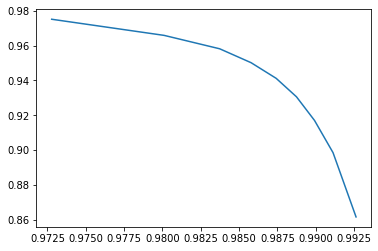

In [120]:
import matplotlib.pyplot as plt

plt.plot(recall.values(), precision.values())
plt.show()

In [121]:
f_1_score = []
for k, v in precision.items():
    f_1_score.append(2 * v * recall[k] / (v + recall[k]))